In [1]:
pathout = '..'

import sys
sys.path.append(pathout)
from TheModel import *

# ---------- SIRS Model of 2 Cooperative Diseases with Seasonality ----------

In [2]:
p={
    'y0':[0.995, 0.005, 0, .005, 0, .005],
    'beta': 5*.08,
    'alpha': .08,
    'gamma': .1,
    'nu': .01,
    'tmin': 0,
    'tmax': 5*360,
    'stepsize': 0.1,      
    'maxstep': 10,
    'direction': True,
    's': 0.25,              # seasonality amplitude
    'w': 2*np.pi/360,        # seasonality frequency (repeats after every 360days)
    'seasonalshift': 0,
    #'distinguishable': doesnt matter bcs we have no Beh Feedback here
}

############################### 'A and B' init. needs higher alpha (0.09) for the first blue lim cycle in 'A)' to cross the basin boarder
InInfComp = 'A and B' ######### 'AB' init. only needs alpha=alpha_crit(epsi=0.5%,C=15)\approx 0.082 for this
############################### as a consequence of increasing alpha to 0.09, the lim cycle regions shift to lower kappa

In [3]:

class model:
    def __init__(self, y0, beta, alpha, gamma, nu, tmin, tmax, stepsize, maxstep, direction, s, w, seasonalshift):
        
        self.y0 = y0
        self.beta = beta
        self.alpha = alpha
        self.gamma = gamma
        self.nu = nu
        self.tmin = tmin
        self.tmax = tmax
        self.stepsize = stepsize
        self.maxstep = maxstep
        self.direction = direction
        self.s = s
        self.w = w
        self.seasonalshift = seasonalshift
        
    # def r_eff(self,t,y):
    #     return self.beta/self.gamma*self.seasonalforcing(t)*self.softplus(y[4])*y[0]-1

    def seasonalforcing(self,t):
        return (1+self.s*np.cos(self.w*(t-self.seasonalshift)))
        
    def fun(self,t,y):
        S,X,P,Q,A,AB = y
        
        dS = -2*self.alpha*self.seasonalforcing(t)*X*S + 2*self.nu*(P-A)
        dX = self.alpha*self.seasonalforcing(t)*X*S + self.beta*self.seasonalforcing(t)*X*P-self.gamma*X
        dP = self.alpha*self.seasonalforcing(t)*X*S - self.beta*self.seasonalforcing(t)*X*P + self.nu*(X-P+Q-2*AB)
        dQ = 2*self.beta*self.seasonalforcing(t)*X*A + 2*self.gamma*(-2*AB+X-A) - 2*self.nu*(Q-AB)
        dA = self.alpha*self.seasonalforcing(t)*X*S - self.beta*self.seasonalforcing(t)*X*A - self.gamma*A + self.nu*(X-AB-A)
        dAB = 2*self.beta*self.seasonalforcing(t)*X*A-2*self.gamma*AB
        return [dS,dX,dP,dQ,dA,dAB]

    def run(self):
        # event1 = lambda t,x: self.i_peaks(t,x)
        # if self.direction:   
        #     event1.direction = -1
            
        # event2 = lambda t,x: self.seasonal_peaks(t,x)
        # event2.direction = -1
        
        # event3 = lambda t,x: self.r_eff(t,x)
        # event3.direction = 1
        
        # event4 = lambda t,x: self.r_eff(t,x)
        # event4.direction = -1
    

        toutput = np.arange(self.tmin, self.tmax, self.stepsize)
        res = solve_ivp(self.fun, (self.tmin,self.tmax), self.y0, t_eval=toutput, max_step = self.maxstep, rtol = 1e-6, atol = 1e-9)#,events=[event1,event2,event3,event4])
        self.times = res['t']
        self.data = res['y']

        # self.events = res['y_events']
        # self.t_events = res['t_events']
        return self.times, self.data #, self.events, self.t_events

def VarToCompartments(S,X,P,Q,A,AB):
    ab = Q-AB
    Ab = X-A-AB
    a = P-A
    return S,A,AB,Ab,a,ab

## Example (incl seasonality)

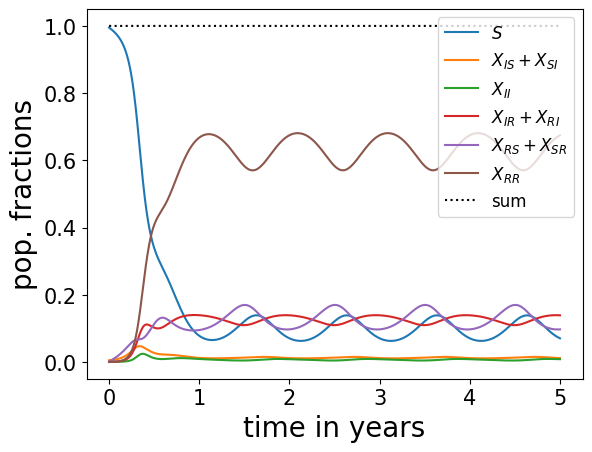

In [4]:
epsi = .005
C = 15
p['alpha'] = .09
p['beta'] = C*p['alpha']
p['gamma'] = 0.1
p['nu'] = 0.01
SetInCondredSIRS(epsi, p, InInfComp)


m = model(**p)
times, Data = m.run()
times /= 360 # convert to years
S, X, P, Q, A, AB = Data
S,A,AB,Ab,a,ab = VarToCompartments(S, X, P, Q, A, AB)

plt.plot(times,S,label=r'$S$')
plt.plot(times,2*A,label=r'$X_{IS}+X_{SI}$')#label='A+B')
plt.plot(times,AB,label=r'$X_{II}$')#label='AB')
plt.plot(times,2*Ab,label=r'$X_{IR}+X_{RI}$')#label='Ab+aB')
plt.plot(times,2*a,label=r'$X_{RS}+X_{SR}$')#label='a+b')
plt.plot(times,ab,label=r'$X_{RR}$')#label='ab')

plt.plot(times,S+2*A+AB+2*Ab+2*a+ab,label='sum',c='k',ls=':')
plt.legend(loc='upper right')
plt.xlabel(r'time in years')
plt.ylabel('pop. fractions')
plt.xticks(np.array([0,1,2,3,4,5]))
plt.savefig('img/SIRSs_Example_NN.pdf', bbox_inches='tight')
plt.show()

## Analysis

In [ ]:
C = 15
epsi = .005

SeasLoops_peryear = np.logspace(-1,.3,60)
fraction = SeasLoops_peryear
s_values = np.logspace(-0.5,0,60)

################################# Endemic and Unstable Equilibrium for different C=15 ################################
#Analytical
alpha_EE, Rinf_unstEq, R_inf_endEq = np.load(pathout+f'/Symmetric Model (+s)/Data/DataSIRS_EE_analytical_C={C}.npy')
R0_EE = alpha_EE/0.1   # kappa = 1 in this data. Later can use this for all kappa, because kappa always cancels in R0 = alpha/gamma.
TheMask = R0_EE <= 1
######################################################################################################################

alpha_crit for Main Case = 0.08227272727272728 but we use the one on UnstableEE =  0.09


In [5]:
p['seasonalshift'] = 0
p['w'] = 2*np.pi/360
SetInCondredSIRS(epsi, p, InInfComp)

1

### A) First $\delta=0\Rightarrow\alpha =0.09\approx \alpha_{\rm crit}(C=15,\epsilon=0.005)$, for different $\kappa=\omega$ and $s$

In [6]:
p['alpha'] = alpha_atUnstEE
C = 15
p['beta'] = C*p['alpha']

#### Lim cycles for diff Ratefrac and diff $s$

C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_13356\2114712693.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  if(k==0): ax1.legend()


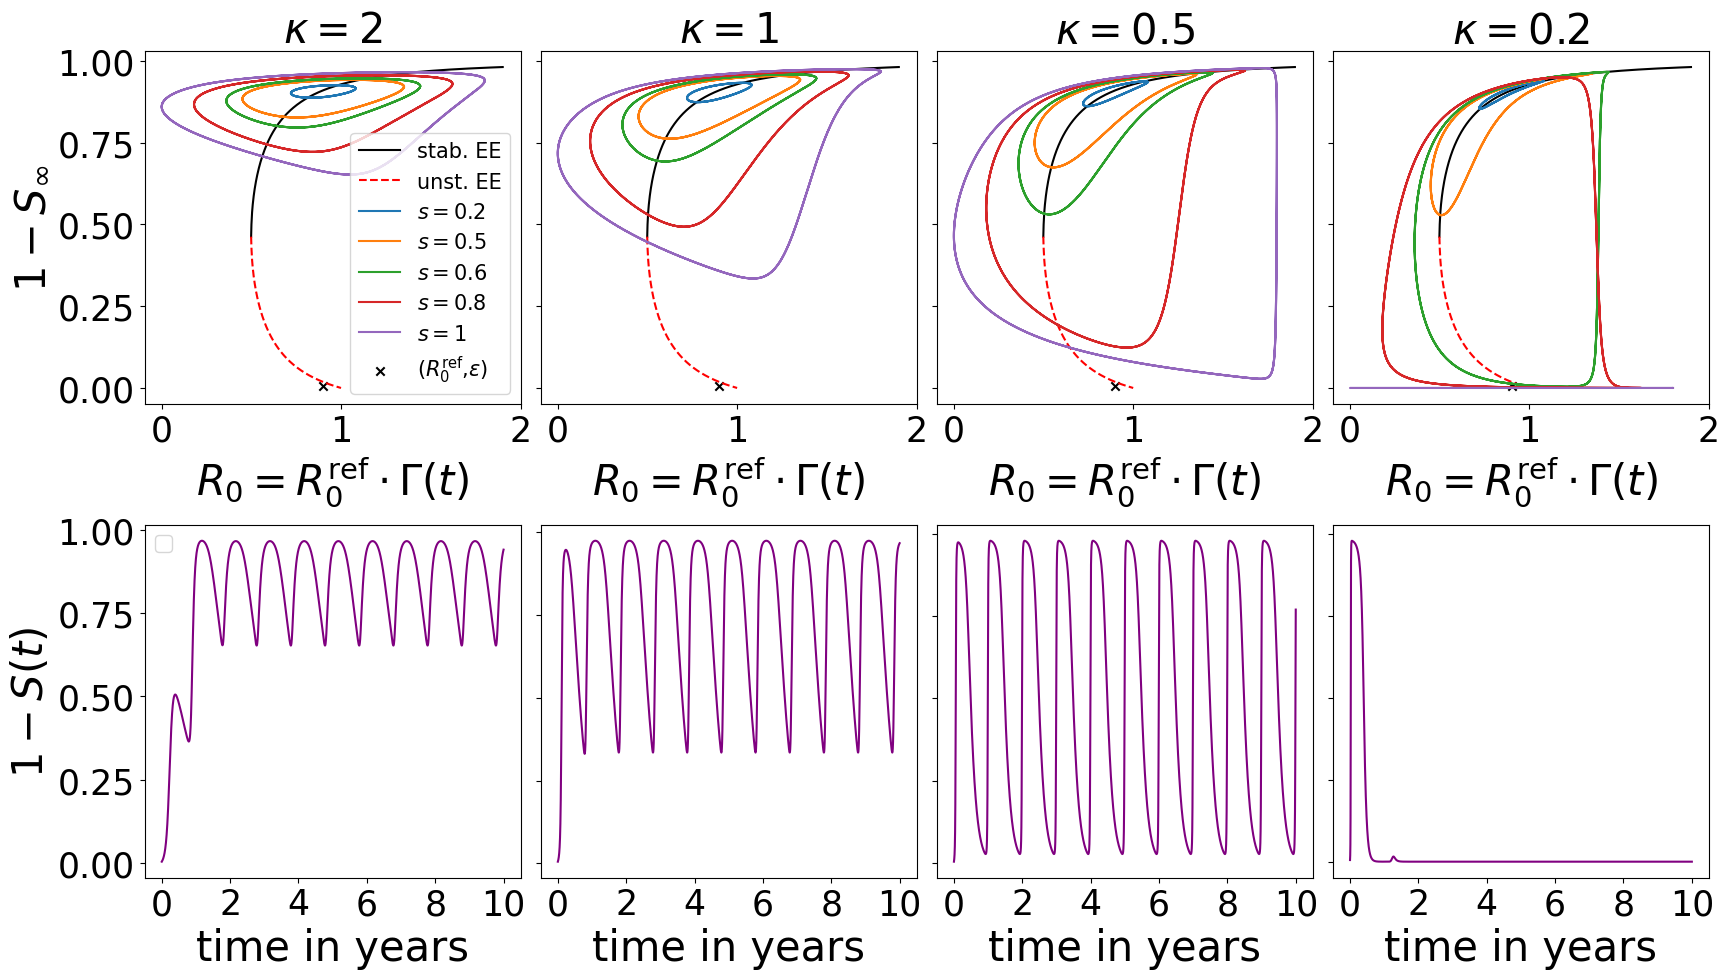

In [76]:
C = 15
p['w'] = 2*np.pi/360 # t in days now with SLoopsPYear = 1

fraction = [2,1,.5,.2]
s_values = [.2,.5,.6,.8,1]

plt.rcParams['font.size'] = 30
plt.rcParams['xtick.labelsize'] = 25
plt.rcParams['ytick.labelsize'] = 25
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['axes.titlesize'] = 30

fig, axes = plt.subplots(2, 4, figsize=(18, 10.5))

for k in range(len(fraction)):
    
    p['gamma'] = .1/fraction[k]
    p['alpha'] = alpha_atUnstEE/fraction[k]
    p['nu'] = .01/fraction[k]
    p['beta'] = C*p['alpha']
    s = 1
    p['s'] = s
    p['tmax'] = 10*360 # t in days now with SLoopsPYear = 1
    cut = int(p['tmax']/p['stepsize']*7/10)
    
    m = model(**p)
    times, Data = m.run()
    times /= 360 # convert to years
    S,X,P,Q,A,AB  = Data
    
    ax1 = axes[1, k] 
    ax1.plot(times, 1-S, c='purple')
    #ax1.plot(times, S, label=r'$S(t)$')
    #ax1.plot(times, P, label=r'$P(t)$')
    #ax1.plot(times, X, label=r'$I(t)$')
    #plt.plot(times,Q, label=rf'Q')
    #plt.plot(times,A, label=rf'A')
    #plt.plot(times,AB, label=rf'AB')
    #plt.plot(times,X,label='X')
    ax1.set_xlabel(r'time in years')
    if(k==0): ax1.set_ylabel(r'$1-S(t)$')
    else: ax1.tick_params(labelleft=False)
    #ax1.set_title(rf'Time evolution for $s =$ {s}')
    ax1.set_xticks([0,2,4,6,8,10],labels=['0','2','4','6','8','10'])
    if(k==0): ax1.legend()
    
    ###################################################
    
    # Limit cycles in seasonality vs R_infty for different s

    ax2 = axes[0, k]

    ax2.plot(R0_EE, R_inf_endEq, ls='-', c='k', label='stab. EE')
    ax2.plot(R0_EE[TheMask], Rinf_unstEq[TheMask], ls='--', c='r', label='unst. EE')
    
    for s in s_values:
        p['s'] = s
        m = model(**p)
        times, Data = m.run()
        times = times[cut:]
        SF = m.seasonalforcing(times)
        S,X,P,Q,A,AB = Data[:,cut:]
        
        ax2.plot(p['alpha'] * SF/p['gamma'], 1 - S, label=rf'$s=${s}')
    
    # ax2.set_xlim(-.1,max(p['alpha']*SF/p['gamma']+.1))
    ax2.scatter(p['alpha']/p['gamma'], epsi, marker='x', c='k', label=r'($R_0^{\rm ref}$,$\epsilon$)')
    ax2.set_xlabel(r'$R_0= R_0^{\rm ref} \cdot \Gamma(t)$')
    if(k==0): ax2.set_ylabel(r'$1-S_\infty$')
    else: ax2.tick_params(labelleft=False)
    if(k==0): ax2.legend()
    ax2.set_title(rf'$\kappa=${fraction[k]}')
    ax2.set_xticks([0,1,2],labels=['0','1','2'])

plt.tight_layout(w_pad=0.1, h_pad=0.2)
plt.savefig('img/SIRSs_LimitCycles_at_delta=0_fordiff_RateFractions_s.pdf', bbox_inches='tight')
plt.show()

plt.rcParams['font.size'] = 20
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.titlesize'] = 20

p['gamma'] = .1
p['alpha'] = alpha_atUnstEE
p['beta'] = C*p['alpha']
p['nu'] = .01

Collapsing into disease free FP:

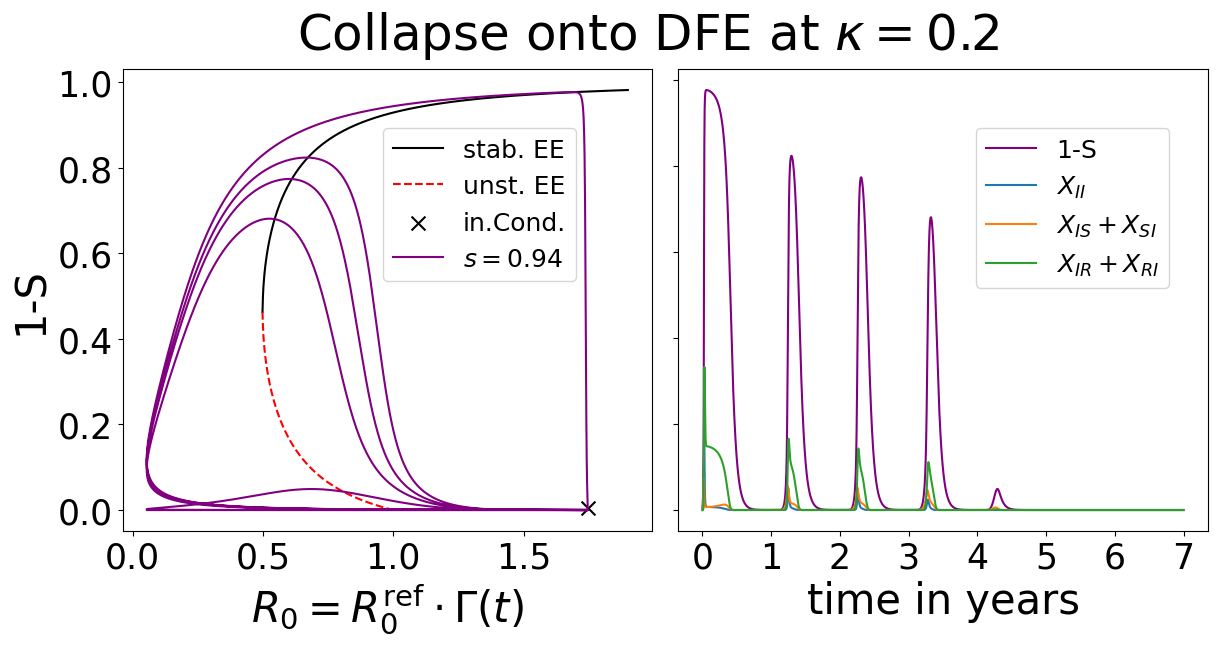

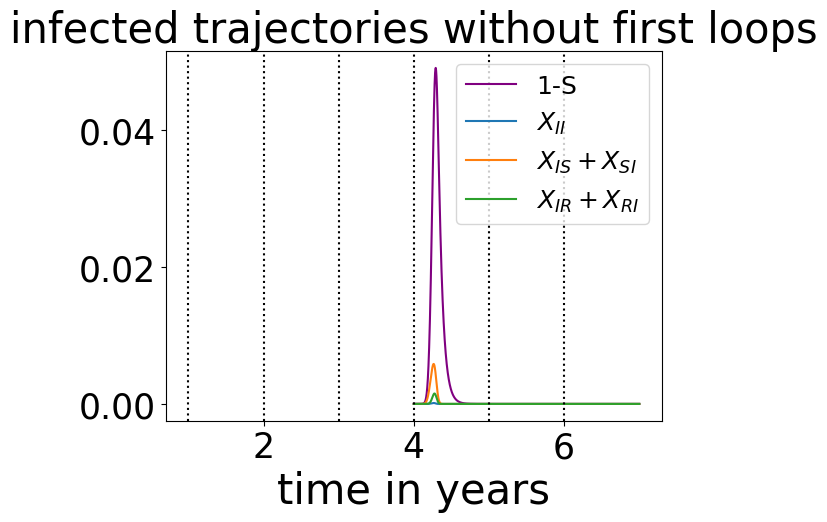

In [87]:
s = .94 # collaps between .92 and .93  (for SL=.2)
p['s'] = s
kappa = .2 # how many seas loops in a year # collapse between .19 and .20 (s=.93)
N_loops = 7 # how many seas loops are simulated
p['w'] = 2*np.pi/360
p['tmax'] = N_loops*360

p['nu'] = .01/kappa
p['gamma'] = .1/kappa
p['alpha'] = alpha_atUnstEE/kappa
C = 15
p['beta'] = C*alpha_atUnstEE/kappa

cuts = lambda Loop: (int(Loop*360/p['stepsize']))

####### TO PLAY: which seasonality loop you want to see ########
cut1 = cuts(0) #N_loops-5)
cut2 = cuts(N_loops)
################################################################

plt.rcParams['font.size'] = 30
plt.rcParams['xtick.labelsize'] = 25
plt.rcParams['ytick.labelsize'] = 25
plt.rcParams['legend.fontsize'] = 18
plt.rcParams['axes.titlesize'] = 30

fig, axes = plt.subplots(1,2, figsize=(14, 6), gridspec_kw={'wspace':0.05})

m = model(**p)
times, Data = m.run()
times = times[:]
SF = m.seasonalforcing(times)
S,X,P,Q,A,AB = Data[:,:]
S,A,AB,Ab,a,ab = VarToCompartments(S, X, P, Q, A, AB)

axes[0].plot(R0_EE, R_inf_endEq, ls='-', c='k', label='stab. EE')
axes[0].plot(R0_EE[TheMask], Rinf_unstEq[TheMask], ls='--', c='r', label='unst. EE')
axes[0].scatter(p['alpha']/p['gamma']*(1+s),epsi,marker='x',s=100,c='k',label=r'in.Cond.') #: $R_0^{\rm ref}(1+s)$, $\epsilon$')

axes[0].plot(p['alpha']*SF[cut1:cut2]/p['gamma'],1-S[cut1:cut2], c='purple',label=rf'$s=${s}')#,ls='--')

axes[0].set_xlabel(r'$R_0= R_0^{\rm ref} \cdot \Gamma(t)$')
fig.suptitle(f'Collapse onto DFE at $\\kappa=${kappa}')
axes[0].set_ylabel('1-S')
axes[0].legend(loc='upper right', bbox_to_anchor=(0,0,.88,.9))

axes[1].plot(times/360,1-S,label='1-S', c='purple')
axes[1].plot(times/360,AB,label=r'$X_{II}$')
axes[1].plot(times/360,2*A,label=r'$X_{IS}+X_{SI}$')
axes[1].plot(times/360,2*Ab,label=r'$X_{IR}+X_{RI}$')
# for loop in range(N_loops-1):
#     axes[1].axvline(x=(loop+1),ls=':',c='k')
axes[1].set_xticks(np.arange(0,N_loops+1))
axes[1].set_xlabel(r'time in years')
axes[1].tick_params(labelleft=False)
#axes[1].set_title('time-evolution')
axes[1].legend(loc='upper right', bbox_to_anchor=(0,0,.95,.9))
plt.savefig('img/SIRSs_CollapseToDFE_example.pdf', bbox_inches='tight')
plt.show()

############################

cutfirstloops = cuts(4)

plt.plot(times[cutfirstloops:]/360,1-S[cutfirstloops:],label='1-S', c='purple')
plt.plot(times[cutfirstloops:]/360,AB[cutfirstloops:],label=r'$X_{II}$')
plt.plot(times[cutfirstloops:]/360,2*A[cutfirstloops:],label=r'$X_{IS}+X_{SI}$')
plt.plot(times[cutfirstloops:]/360,2*Ab[cutfirstloops:],label=r'$X_{IR}+X_{RI}$')
for loop in range(N_loops-1):
    plt.axvline(x=(loop+1),ls=':',c='k')
plt.xlabel(r'time in years')
plt.title('infected trajectories without first loops')
plt.legend()
plt.show()

plt.rcParams['font.size'] = 20
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.titlesize'] = 20

To play:

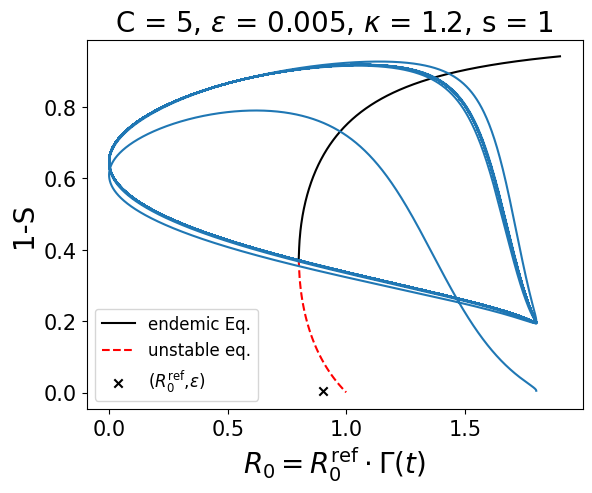

In [ ]:
epsi_values = [.001,.005,.01,.1] # for axes[2]
C_values = [5,15,40,100] #[10,15,30,60]        # for axes[1]

#########################
Idx = 0
epsi = 0.005
s = 1
SL = 1.2 # =kappa
#########################

C = C_values[Idx]

alpha_EE_Play, Rinf_unstEq_Play, R_inf_endEq_Play = np.load(pathout+f'/Symmetric Model (+s)/Data/DataSIRS_EE_analytical_C={C}.npy')
R0_EE_Play = alpha_EE_Play/0.1
TheMask_Play = R0_EE_Play <= 1

SetInCondredSIRS(epsi, p, InInfComp)
p['alpha'] = alpha_atUnstEE
p['beta'] = C*p['alpha']
p['gamma'] = .1
p['nu'] = .01
p['s'] = s
N_loops = 40 # how many seas loops are simulated
p['w'] = 2*np.pi/360*SL
p['tmax'] = N_loops*360/SL

cuts = lambda Loop: (int(Loop*360/SL/p['stepsize']))

####### TO PLAY: which seasonality loop you want to see ########
cut1 = cuts(0)
cut2 = cuts(N_loops)
################################################################

m = model(**p)
times, Data = m.run()
times = times[:]
SF = m.seasonalforcing(times)
S,X,P,Q,A,AB = Data[:,:]
    
plt.plot(R0_EE_Play, R_inf_endEq_Play, ls='-', c='k', label='stab. EE')
plt.plot(R0_EE_Play[TheMask_Play], Rinf_unstEq_Play[TheMask_Play], ls='--', c='r', label='unst. EE')
plt.scatter(p['alpha']/p['gamma'],epsi,marker='x',c='k',label=r'($R_0^{\rm ref}$,$\epsilon$)')

plt.plot(p['alpha']*SF[cut1:cut2]/p['gamma'],1-S[cut1:cut2])

plt.xlabel(r'$R_0= R_0^{\rm ref} \cdot \Gamma(t)$')
plt.title(f'C = {C}, $\epsilon$ = {epsi}, $\\kappa$ = {SL}, s = {s}')
plt.ylabel('1-S')
plt.legend()
plt.show()

#### Heatmap of $\langle 1-S_\infty\rangle$ (incl Type of attractor) for fixed $C=15$ and $\epsilon=0.005$

In [ ]:
Peaks = np.empty((len(s_values),len(fraction),2)) # last "2" is [PeakValue, LimiCycleYesOrNo] to know whether its a limit cycle (1) or not (0)

SetInCondredSIRS(epsi, p, InInfComp)

for s_idx in range(len(s_values)):
    for k in range(len(fraction)):
        print('computing s =',s_values[s_idx],'and fraction =',fraction[k])

        Years_evol = 25
        # if(fraction[k]<.4): Years_evol = 25
        # else: Years_evol = 100 # because here some fixpoints

        p['gamma'] = .1/fraction[k]
        p['alpha'] = alpha_atUnstEE/fraction[k] 
        p['nu'] = .01/fraction[k]
        p['beta'] = C*alpha_atUnstEE/fraction[k] 
        
        p['tmax'] = Years_evol*360/fraction[k]
        cut = int(p['tmax']/p['stepsize']*7/10)

        
        p['s'] = s_values[s_idx]
        m = model(**p)

        try:
            times, Data = m.run()
            times = times[cut:]
            S,X,P,Q,A,AB = Data[:,cut:]
            SF = m.seasonalforcing(times)
            Mean_R = np.mean(1-S)
            FOI = p['alpha'] * SF

            if(np.max(FOI)-np.min(FOI)<.015 or np.max(1-S)-np.min(1-S)<.002): # Fixpoint
                Peaks[s_idx, k, 0] = np.mean(1-S)
                Peaks[s_idx, k, 1] = 0
                continue
            else: 
                if(CheckIfPeriodic(FOI,ACI_thresh=.75) and CheckIfPeriodic(1-S,ACI_thresh=.75)): # periodic
                    found_NotPeriodic = False
                else:
                    found_NotPeriodic = True

                        
                if(found_NotPeriodic): # not periodic
                    Peaks[s_idx, k, 0] = np.mean(1-S) 
                    Peaks[s_idx, k, 1] = 2
                    continue
                else: # limit cycle
                    Peaks[s_idx, k, 0] = np.mean(1-S)
                    Peaks[s_idx, k, 1] = 1
        
        except RuntimeError as errormessage:
            print(errormessage)
            Peaks[s_idx, k, 0] = -1
            Peaks[s_idx, k, 1] = -1
            pass

np.save(f'Data/DataSIRSs_HeatmapOfLimCycleMean1-S_s_vs_fraction.npy', Peaks)

computing s = 0.31622776601683794 and fraction = 0.03162277660168379
computing s = 0.31622776601683794 and fraction = 0.039331167860186915
computing s = 0.31622776601683794 and fraction = 0.048918562235418336
computing s = 0.31622776601683794 and fraction = 0.06084298690766427
computing s = 0.31622776601683794 and fraction = 0.07567411809920191
computing s = 0.31622776601683794 and fraction = 0.09412049672680671
computing s = 0.31622776601683794 and fraction = 0.11706337816171067
computing s = 0.31622776601683794 and fraction = 0.14559883323191877
computing s = 0.31622776601683794 and fraction = 0.181090111795782
computing s = 0.31622776601683794 and fraction = 0.2252327704987382
computing s = 0.31622776601683794 and fraction = 0.2801356761198869
computing s = 0.31622776601683794 and fraction = 0.3484217543538399
computing s = 0.31622776601683794 and fraction = 0.43335329718965926
computing s = 0.31622776601683794 and fraction = 0.5389878153085523
computing s = 0.31622776601683794 and 

In [ ]:
def PlotSIRSs_HeatmapOfLimCycleMean_s_vs_fraction():

    Peaks = np.load(f"Data/DataSIRSs_HeatmapOfLimCycleMean1-S_s_vs_fraction.npy")

    plt.rcParams['font.size'] = 30
    plt.rcParams['xtick.labelsize'] = 20
    plt.rcParams['ytick.labelsize'] = 20
    plt.rcParams['legend.fontsize'] = 18
    plt.rcParams['axes.titlesize'] = 30

    # # Create a custom colormap
    # import matplotlib.colors as mcolors
    # cmap_spring = plt.get_cmap('spring')
    # colors = [(0, 0, 0, 1)] + [cmap_spring(i / 255) for i in range(256)]
    # custom_cmap = mcolors.ListedColormap(colors)
    # norm = mcolors.BoundaryNorm(boundaries=[0, 0.1, 1], ncolors=256)

    from matplotlib.colors import LinearSegmentedColormap
    Val1 = 0.133
    Val2 = 0.908
    ColStep = (Val2-Val1)/5
    colors = [
        (0.0, 'k'), (0.005, 'k'), (0.005, 'grey'), (Val1, 'grey'),
        (Val1, 'orangered'), (Val1+ColStep, 'orangered'), (Val1+ColStep, 'darkorange'), (Val1+ColStep*2, 'darkorange'), 
        (Val1+ColStep*2, 'orange'), (Val1+ColStep*3, 'orange'), (Val1+ColStep*3, 'gold'), (Val1+ColStep*4, 'gold'), 
        (Val1+ColStep*4, 'yellow'), (Val2, 'yellow'), (Val2, 'grey'), (1, 'grey')
    ]
    cmap = LinearSegmentedColormap.from_list('custom_cmap', colors)

    for s_idx in range(len(s_values)):
        for k in range(len(fraction)):
            if(Peaks[s_idx,k,1] == -1): plt.scatter(s_values[s_idx],fraction[k],c='k',marker='x',s=65) # ERROR
            else:
                if(Peaks[s_idx,k,1] == 1): use_marker = 'o' # its a limit cycle
                elif(Peaks[s_idx,k,1] == 2): use_marker = 'o' # its not periodic. actually periodic (checked individually)
                else: use_marker = '$F$' # its a fixpoint
                
                if(Peaks[s_idx,k,0] <= 0.1): plt.scatter(s_values[s_idx],fraction[k],c='k',marker=use_marker,s=65)
                else: cax = plt.scatter(s_values[s_idx],fraction[k],c=Peaks[s_idx,k,0],vmin=0,vmax=1,marker=use_marker,s=65,cmap=cmap) #cmap=custom_cmap,norm=norm)
    plt.xlabel(r'$s$')
    plt.ylabel(r'$\kappa$')
    plt.xscale('log')
    plt.yscale('log')
    plt.xticks([.3,.4,.5,.6,.8,1],labels=[.3,.4,.5,.6,.8,1])
    plt.yticks([.04,.1,.2,.4,1,2],labels=[.04,.1,.2,.4,1,2])
    plt.colorbar(cax, label=r'$\langle 1-S_\infty\rangle$')
    
    plt.rcParams['font.size'] = 20
    plt.rcParams['xtick.labelsize'] = 15
    plt.rcParams['ytick.labelsize'] = 15
    plt.rcParams['legend.fontsize'] = 12
    plt.rcParams['axes.titlesize'] = 20
    return 0

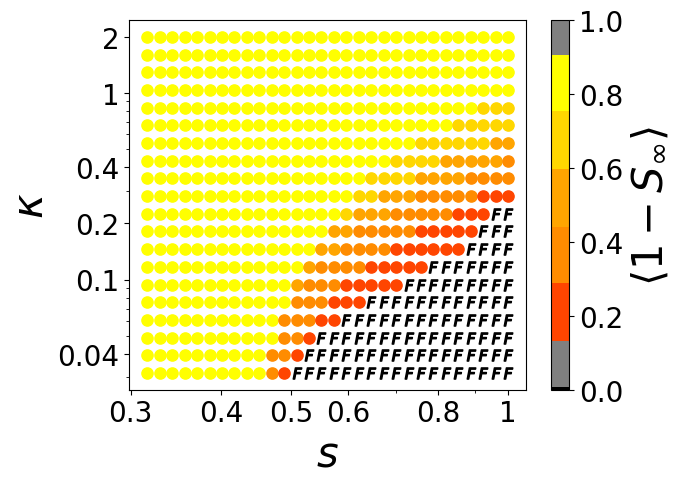

In [93]:
PlotSIRSs_HeatmapOfLimCycleMean_s_vs_fraction()
plt.savefig(f'img/SIRSs_HeatmapOfLimCycleMean1-S_s_vs_fraction.pdf', bbox_inches='tight')
plt.show()

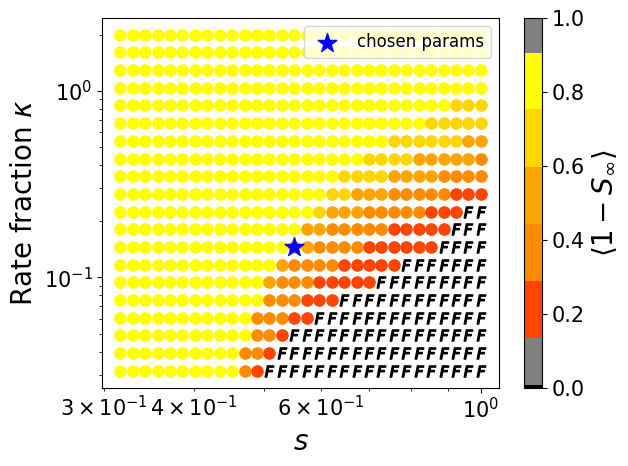

s= 0.5512889788770674 fraction= 0.14559883323191877 1-S= [0.51729713 2.        ]
This one is not periodic


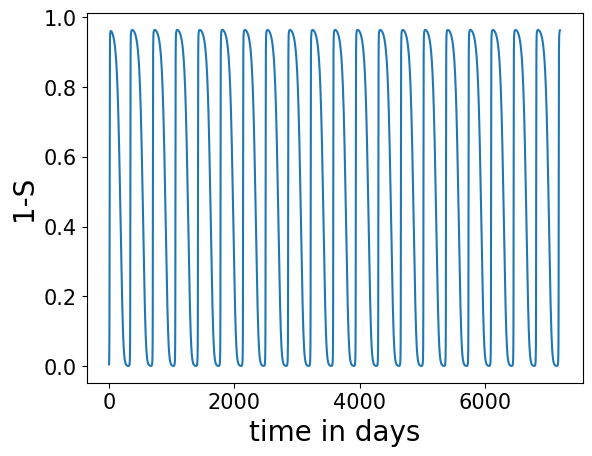

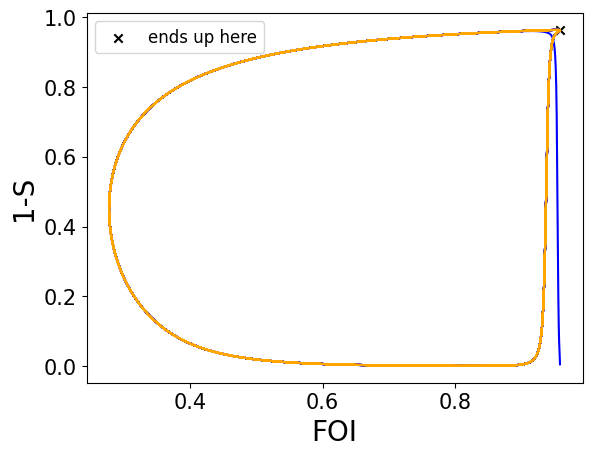

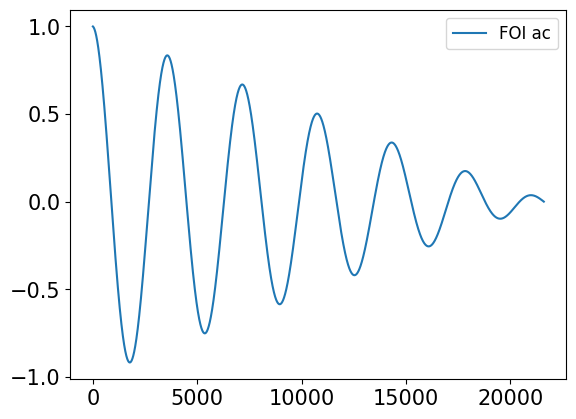

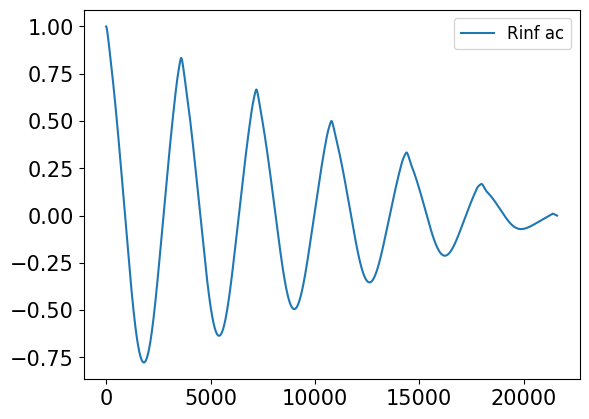

In [16]:
# Check trajectories

Peaks = np.load(f"Data/DataSIRSs_HeatmapOfLimCycleMean1-S_s_vs_fraction.npy")

######################
s_idx = 14
k = 7
Years_evol = 20
######################

PlotSIRSs_HeatmapOfLimCycleMean_s_vs_fraction()
plt.scatter(s_values[s_idx],fraction[k],c='b',marker='*',s=200,label='chosen params')
plt.legend()
plt.show()

print('s=',s_values[s_idx],'fraction=',fraction[k],'1-S=',Peaks[s_idx,k])
if(Peaks[s_idx,k,1] == -1): print('This one gave error')
elif(Peaks[s_idx,k,1] == 1): print('This one is a limit cycle')
elif(Peaks[s_idx,k,1] == 2): print('This one is not periodic')
else: print('This one is a fixpoint')

SetInCondredSIRS(epsi, p, InInfComp)

p['gamma'] = .1/fraction[k]
p['alpha'] = alpha_atUnstEE/fraction[k] 
p['nu'] = .01/fraction[k]
p['beta'] = C*p['alpha']
p['tmax'] = Years_evol*360
cut = int(p['tmax']/p['stepsize']*7/10)


p['s'] = s_values[s_idx]
m = model(**p)
times, Data = m.run()
SF = m.seasonalforcing(times)
S,X,P,Q,A,AB = Data[:,:]
FOI = p['alpha']*SF[:]

plt.ylabel('1-S')
plt.xlabel('time in days')
plt.plot(times,1-S)
plt.show()

plt.plot(FOI[:cut], 1-S[:cut], c='blue')
plt.plot(FOI[cut:], 1-S[cut:], c='orange')
plt.scatter(FOI[-1],1-S[-1],label='ends up here',marker='x',c='k')
plt.xlabel('FOI')
plt.ylabel('1-S')
plt.legend()
plt.show()

#CUT DATA

S,X,P,Q,A,AB = Data[:,cut:]
times = times[cut:]
FOI = p['alpha']*SF[cut:]

# peak_idces, _ = scp.signal.find_peaks(1-S)
# print(1-S[peak_idces])

# import nolds
# LE = nolds.lyap_r(1-S)
# print('LE =',LE)

# Normalize time series
FOI_forac = (FOI - np.mean(FOI)) / np.std(FOI)
Rinf_forac = (1-S - np.mean(1-S)) / np.std(1-S)
# Calculate the autocorrelation function
FOI_ac = np.correlate(FOI_forac, FOI_forac, mode='full')
FOI_ac = FOI_ac[FOI_ac.size // 2:] # only second half
Rinf_ac = np.correlate(Rinf_forac, Rinf_forac, mode='full')
Rinf_ac = Rinf_ac[Rinf_ac.size // 2:]
# Normalize the autocorrelation function
FOI_ac = FOI_ac / np.max(FOI_ac)
Rinf_ac = Rinf_ac / np.max(Rinf_ac)

plt.plot(FOI_ac, label='FOI ac')
plt.legend()
plt.show()

plt.plot(Rinf_ac, label='Rinf ac')
plt.legend()
plt.show()

#### Heatmap For Paper

In [ ]:
fraction = np.logspace(-1.5,.3,20)  # For AB(0) we used: np.logspace(-0.7,.3,20) starting with frac=kappa=seasloops=10^-0.92 => 0.12 = alpha, to mantain rates below 1. Else: populations go below 0 in simulation.
s_values = np.logspace(-0.8,0,30)

################## Colormap #######################
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.cm as cm
cm_spring = cm.get_cmap("spring")
Val0 = 0.12
Val1 = 0.158
Val2 = 0.908
ColStep = (Val2-Val1)/5
colors = [
    (0.0, 'k'), (0.001, 'k'), (0.001, 'grey'), (Val0, 'grey'), (Val0, cm_spring(0)), (Val1, cm_spring(0)),
    (Val1, 'brown'), (Val1+ColStep, 'brown'), (Val1+ColStep, 'orangered'), (Val1+ColStep*2, 'orangered'), 
    (Val1+ColStep*2, 'darkorange'), (Val1+ColStep*3, 'darkorange'), (Val1+ColStep*3, 'gold'), (Val1+ColStep*4, 'gold'), 
    (Val1+ColStep*4, 'yellow'), (Val2, 'yellow'), (Val2, 'yellow'), (1, 'yellow')
] # changed last colors from orange/gold/yellow to gold/yellow/yellow (see 'Non matching Heatmap' chapter in Symmetric Model +sm.ipynb)
cmap = LinearSegmentedColormap.from_list('custom_cmap', colors)

# # Create a custom colormap
# import matplotlib.colors as mcolors
# cmap_spring = plt.get_cmap('spring')
# colors = [(0, 0, 0, 1)] + [cmap_spring(i / 255) for i in range(256)]
# custom_cmap = mcolors.ListedColormap(colors)
# norm = mcolors.BoundaryNorm(boundaries=[0, 0.1, 1], ncolors=256)

# # COLORBLIND FRIENDLY VERSION (BUT UGLY COLORS)
# from matplotlib.colors import LinearSegmentedColormap
# Col1 = 'grey'# '#70362D'
# Col2 = '#8D475B'
# Col3 = '#916690'
# Col4 = '#728DBB'
# Col5 = '#2EB3CB'
# Col6 = '#15D5B8'
# Col7 = '#80EF8F'
# Col8 = '#E6FE67'
# Val1 = 0.133
# Val2 = 0.908
# ColStep = (Val2-Val1)/6
# colors = [
#     (0.0, 'k'), (0.001, 'k'), (0.001, Col1), (Val1-ColStep/8, Col1),
#     (Val1-ColStep/8, Col2), (Val1+ColStep, Col2), (Val1+ColStep, Col3), (Val1+ColStep*2, Col3), 
#     (Val1+ColStep*2, Col4), (Val1+ColStep*3, Col4), (Val1+ColStep*3, Col5), (Val1+ColStep*4, Col5), 
#     (Val1+ColStep*4, Col6), (Val2-ColStep,Col7), (Val2-ColStep, Col7), (Val2, Col8), (1, Col8)
# ]
# cmap = LinearSegmentedColormap.from_list('custom_cmap', colors)

C:\Users\PCUser\AppData\Local\Temp\ipykernel_24204\2712322251.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm_spring = cm.get_cmap("spring")


In [ ]:
Peaks = np.empty((len(s_values),len(fraction),2)) # last "2" is [PeakValue, LimiCycleYesOrNo] to know whether its a limit cycle (1) or not (0)

SetInCondredSIRS(epsi, p, InInfComp)

for s_idx in range(len(s_values)):
    for k in range(len(fraction)):
        print('computing s =',s_values[s_idx],'and fraction =',fraction[k])

        Years_evol = 25
        # if(fraction[k]<.4): Years_evol = 25
        # else: Years_evol = 100 # because here some fixpoints

        p['gamma'] = .1/fraction[k]
        p['alpha'] = alpha_atUnstEE/fraction[k] 
        p['nu'] = .01/fraction[k]
        p['beta'] = C*alpha_atUnstEE/fraction[k] 
        
        p['tmax'] = Years_evol*360/fraction[k]
        cut = int(p['tmax']/p['stepsize']*7/10)

        
        p['s'] = s_values[s_idx]
        m = model(**p)

        try:
            times, Data = m.run()
            times = times[cut:]
            S,X,P,Q,A,AB = Data[:,cut:]
            SF = m.seasonalforcing(times)
            Mean_R = np.mean(1-S)
            FOI = p['alpha'] * SF

            if(np.max(FOI)-np.min(FOI)<.015 or np.max(1-S)-np.min(1-S)<.002): # Fixpoint
                Peaks[s_idx, k, 0] = np.mean(1-S)
                Peaks[s_idx, k, 1] = 0
                continue
            else:
                if(CheckIfPeriodic(FOI,ACI_thresh=.75) and CheckIfPeriodic(1-S,ACI_thresh=.75)): # periodic
                    found_NotPeriodic = False
                else:
                    found_NotPeriodic = True

                        
                if(found_NotPeriodic): # not periodic
                    Peaks[s_idx, k, 0] = np.mean(1-S) 
                    Peaks[s_idx, k, 1] = 2
                    continue
                else: # limit cycle
                    Peaks[s_idx, k, 0] = np.mean(1-S)
                    Peaks[s_idx, k, 1] = 1
        
        except RuntimeError as errormessage:
            print(errormessage)
            Peaks[s_idx, k, 0] = -1
            Peaks[s_idx, k, 1] = -1
            pass

np.save(f'Data/DataSIRSs_HeatmapOfLimCycleMean1-S_s_vs_fraction_ForPaper.npy', Peaks)

computing s = 0.15848931924611134 and fraction = 0.03162277660168379
computing s = 0.15848931924611134 and fraction = 0.039331167860186915
computing s = 0.15848931924611134 and fraction = 0.048918562235418336
computing s = 0.15848931924611134 and fraction = 0.06084298690766427
computing s = 0.15848931924611134 and fraction = 0.07567411809920191
computing s = 0.15848931924611134 and fraction = 0.09412049672680671
computing s = 0.15848931924611134 and fraction = 0.11706337816171067
computing s = 0.15848931924611134 and fraction = 0.14559883323191877
computing s = 0.15848931924611134 and fraction = 0.181090111795782
computing s = 0.15848931924611134 and fraction = 0.2252327704987382
computing s = 0.15848931924611134 and fraction = 0.2801356761198869
computing s = 0.15848931924611134 and fraction = 0.3484217543538399
computing s = 0.15848931924611134 and fraction = 0.43335329718965926
computing s = 0.15848931924611134 and fraction = 0.5389878153085523
computing s = 0.15848931924611134 and 

In [10]:
def PlotSIRSs_HeatmapOfLimCycleMean_s_vs_fraction():

    Peaks = np.load(f"Data/DataSIRSs_HeatmapOfLimCycleMean1-S_s_vs_fraction_ForPaper.npy")

    print('pink point:',Peaks[-5,6])
    plt.rcParams['font.size'] = 30
    plt.rcParams['xtick.labelsize'] = 20
    plt.rcParams['ytick.labelsize'] = 20
    plt.rcParams['legend.fontsize'] = 18
    plt.rcParams['axes.titlesize'] = 30

    for s_idx in range(len(s_values)):
        for k in range(len(fraction)):
            if(Peaks[s_idx,k,1] == -1): plt.scatter(s_values[s_idx],fraction[k],c='k',marker='x',s=65) # ERROR
            else:
                if(Peaks[s_idx,k,1] == 1): use_marker = 'o' # its a limit cycle
                elif(Peaks[s_idx,k,1] == 2): use_marker = 'o' # its not periodic
                elif(s_idx==0 and k==len(fraction)-1): use_marker = 'o' # lc is too small to be detected
                else: use_marker = '$F$' # its a fixpoint
                
                if(Peaks[s_idx,k,0] <= 0.1): plt.scatter(s_values[s_idx],fraction[k],c='k',marker=use_marker,s=65)
                else: cax = plt.scatter(s_values[s_idx],fraction[k],c=Peaks[s_idx,k,0],vmin=0,vmax=1,marker=use_marker,s=65,cmap=cmap) #cmap=custom_cmap,norm=norm)
    plt.xlabel(r'$s$')
    plt.ylabel(r'$\kappa$')
    plt.xscale('log')
    plt.yscale('log')
    plt.xticks([.2,.3,.4,.6,.8,1],labels=[.2,.3,.4,.6,.8,1])
    plt.yticks([.04,.1,.2,.4,1,2],labels=[.04,.1,.2,.4,1,2])
    plt.colorbar(cax, label=r'$\langle 1-S_\infty\rangle$')
    
    plt.rcParams['font.size'] = 20
    plt.rcParams['xtick.labelsize'] = 15
    plt.rcParams['ytick.labelsize'] = 15
    plt.rcParams['legend.fontsize'] = 12
    plt.rcParams['axes.titlesize'] = 20
    return 0

pink point: [0.13236047 1.        ]


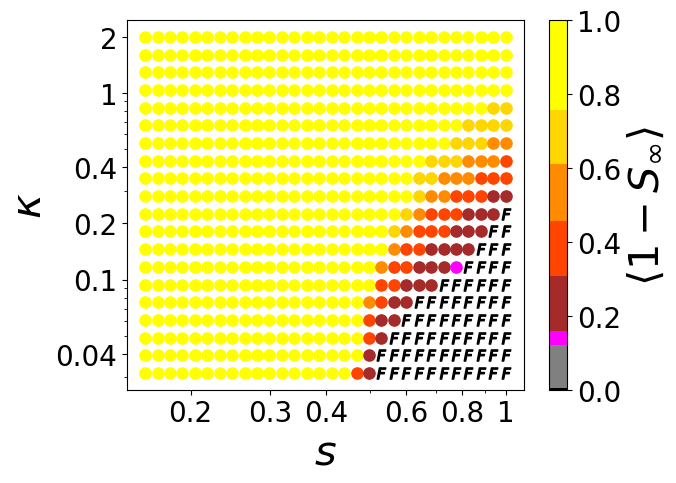

In [11]:
PlotSIRSs_HeatmapOfLimCycleMean_s_vs_fraction()
plt.savefig(f'img/SIRSs_HeatmapOfLimCycleMean1-S_s_vs_fraction_ForPaper.pdf', bbox_inches='tight')
plt.show()

#### Bifurcation Diagram 1-S for diff S and Ratefrac

In [95]:
s_valueList = [
    [0, .25],
    [.25, .5],
    [.5, .75],
    [.75, 1]
]
fraction = [.5,.2,.1,.05]

In [248]:
Peaks = np.zeros((len(s_valueList),len(fraction),100,2))

SetInCondredSIRS(epsi, p, InInfComp)

Counter_Max = 0
for s_val_idx, s_values in enumerate(s_valueList):
    for k in range(len(fraction)):

        p['gamma'] = .1/fraction[k]
        p['alpha'] = alpha_atUnstEE/fraction[k]
        p['nu'] = .01/fraction[k]
        p['beta'] = C*alpha_atUnstEE/fraction[k]
        p['tmax'] = 40*360 # t in days now with SLoopsPYear = 1
        cut = int(p['tmax']/p['stepsize']*7/10)

        counter = 0
        for s in np.linspace(min(s_values),max(s_values),30):
            p['s'] = s

            try: 
                m = model(**p)
                times, Data = m.run()
                S = Data[0,cut:]

                if(np.all(np.array(S[-10:-1])==np.full(9,S[-1]))): 
                    Peaks[mmax_val_idx, k, counter, 0] = mmax
                    Peaks[mmax_val_idx, k, counter, 1] = 1-S[-1]
                    counter += 1
                else:
                    max_idces, _ = scp.signal.find_peaks(1-S)
                    min_idces, _ = scp.signal.find_peaks(S-1)
                    Rinf_maxvalues = set([f"{1-S[idx]:.4f}" for idx in max_idces]) # Only keep values that difer by at least 0.001 (set eliminates equal values)
                    Rinf_minvalues = set([f"{1-S[idx]:.4f}" for idx in min_idces])

                    for Rinf in Rinf_maxvalues:
                        Peaks[s_val_idx, k, counter, 0] = s # s value is only assigned if there is a peak, else it stays at 0 and is not plotted later
                        Peaks[s_val_idx, k, counter, 1] = Rinf
                        counter += 1
                    for Rinf in Rinf_minvalues: 
                        Peaks[s_val_idx, k, counter, 0] = s
                        Peaks[s_val_idx, k, counter, 1] = Rinf
                        counter += 1
            except RuntimeError as errormessage:
                print("at s=",s,"and Ratefraction=",fraction[k],"ERROR:", errormessage)
                pass
        if(counter>Counter_Max): Counter_Max = counter
        print(k+1,'/',len(fraction))
    print('>>>',s_val_idx+1,'/',len(s_valueList))

print('Maximum of points on a plot =',Counter_Max)

np.save('Data/DataSIRSs_BLOCK_LimCyclePeaksBifurcation_s_vs_1-S_fordiff_Ratefractions.npy', Peaks)

1 / 4
2 / 4
3 / 4
4 / 4
>>> 1 / 4
1 / 4
2 / 4
3 / 4
4 / 4
>>> 2 / 4
1 / 4
2 / 4
3 / 4
4 / 4
>>> 3 / 4
1 / 4
2 / 4
3 / 4
4 / 4
>>> 4 / 4
Maximum of points on a plot = 91


1 / 4
2 / 4
3 / 4
4 / 4


C:\Users\Rodrigo Amaral Lind\AppData\Local\Temp\ipykernel_13356\3646788339.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


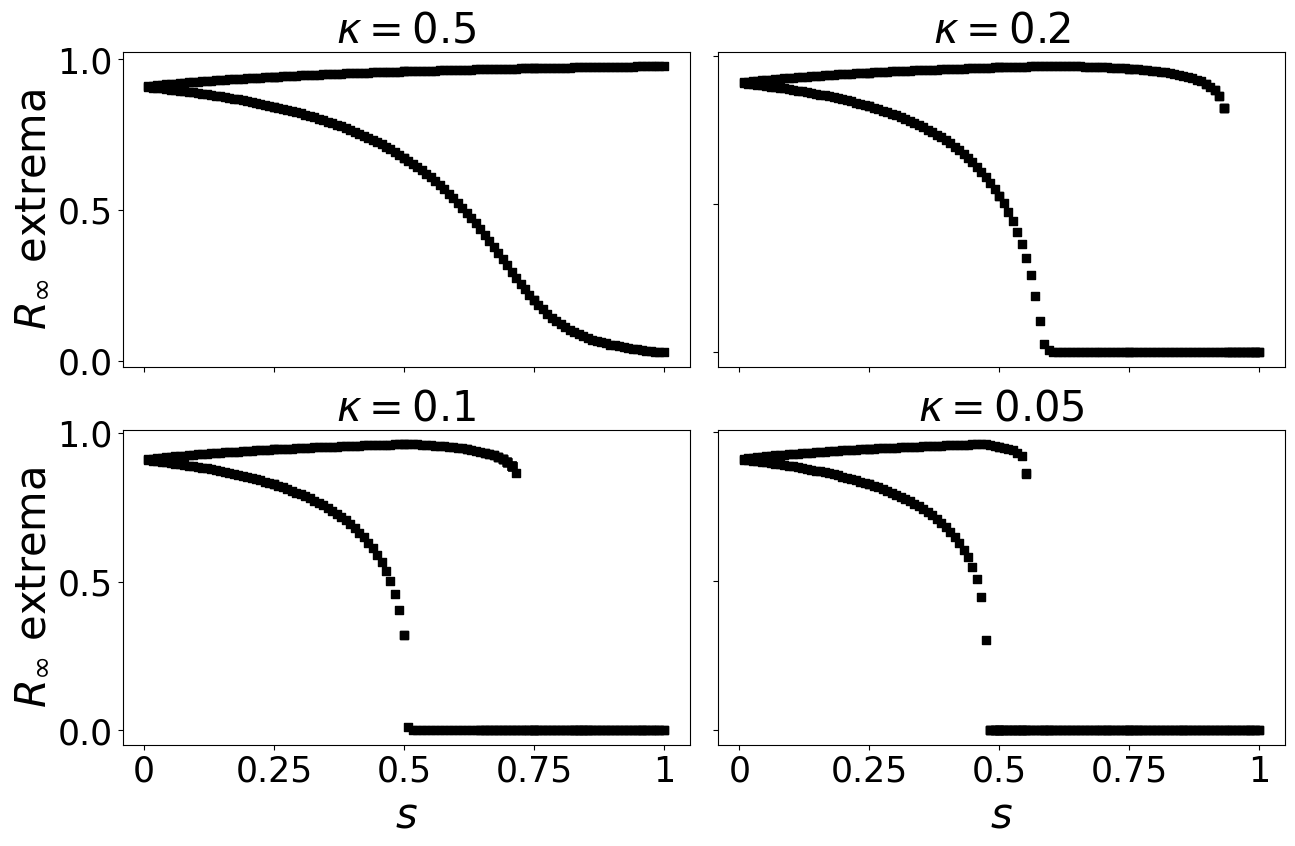

In [97]:
Peaks = np.load('Data/DataSIRSs_BLOCK_LimCyclePeaksBifurcation_s_vs_1-S_fordiff_Ratefractions.npy')

plt.rcParams['font.size'] = 30
plt.rcParams['xtick.labelsize'] = 25
plt.rcParams['ytick.labelsize'] = 25
plt.rcParams['legend.fontsize'] = 15
plt.rcParams['axes.titlesize'] = 30

fig, axes = plt.subplots(2, 2, figsize=(15, 9),gridspec_kw={'wspace': 0.05})

for s_val_idx in range(len(s_valueList)):
    for k in range(len(fraction)):

        ax = axes[k//2, k%2]

        for counter in range(len(Peaks[s_val_idx,k,:,:])): 
            s = Peaks[s_val_idx, k, counter, 0]
            if(s!=0):
                R_inf = Peaks[s_val_idx, k, counter, 1]
                ax.scatter(s, R_inf, marker=',', c='k')
        
        if(k//2==1): ax.set_xlabel(r'$s$')
    
        if(s_val_idx==0): 
            ax.set_title(rf'$\kappa=${fraction[k]}')
            if(k%2==0): ax.set_ylabel(rf'$R_\infty$ extrema')
            else: ax.tick_params(labelleft=False) 
            if(k//2==0): ax.tick_params(labelbottom=False)
            else: ax.set_xticks([0,.25,.5,.75,1],labels=['0',.25,.5,.75,'1'])
    print(s_val_idx+1,'/',len(s_valueList))

plt.tight_layout()
plt.savefig('img/SIRSs_BLOCK_LimCyclePeaksBifurcation_s_vs_1-S_fordiff_Ratefractions.pdf', bbox_inches='tight')
plt.show()

plt.rcParams['font.size'] = 20
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.titlesize'] = 20